# Building a CNN Model for Image Classification
**Dataset:** Intel Image Classification (6 classes: buildings, forest, glacier, mountain, sea, street)  
**Framework:** TensorFlow / Keras

**Outline**
- Part A: Data understanding and preprocessing
- Part B: CNN model development and training
- Part C: Evaluation and interpretation

In [1]:
import os, random, collections
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Part A: Data Understanding and Preprocessing
### A1. Load the dataset
Downloads the dataset with `kagglehub`.
(On Kaggle itself, use `/kaggle/input/intel-image-classification`.)

In [2]:
import kagglehub
DATA_ROOT = kagglehub.dataset_download("puneet6060/intel-image-classification")
# DATA_ROOT = "/path/to/intel-image-classification"   # <- or set manually
print("Dataset root:", DATA_ROOT)

def find_split_dir(root, name):
    """Find the folder called `name` (e.g. seg_train) that directly contains the class folders."""
    for dp, dn, _ in os.walk(root):
        if os.path.basename(dp) == name and 'buildings' in dn:
            return dp
    raise FileNotFoundError(name)

TRAIN_DIR = find_split_dir(DATA_ROOT, "seg_train")
TEST_DIR  = find_split_dir(DATA_ROOT, "seg_test")
print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset root: /kaggle/input/intel-image-classification
Train dir: /kaggle/input/intel-image-classification/seg_train/seg_train
Test dir : /kaggle/input/intel-image-classification/seg_test/seg_test


### A1. Explore structure: classes, counts, image sizes, samples

Number of classes: 6 ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: {'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382} | total = 14034
Test : {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501} | total = 3000


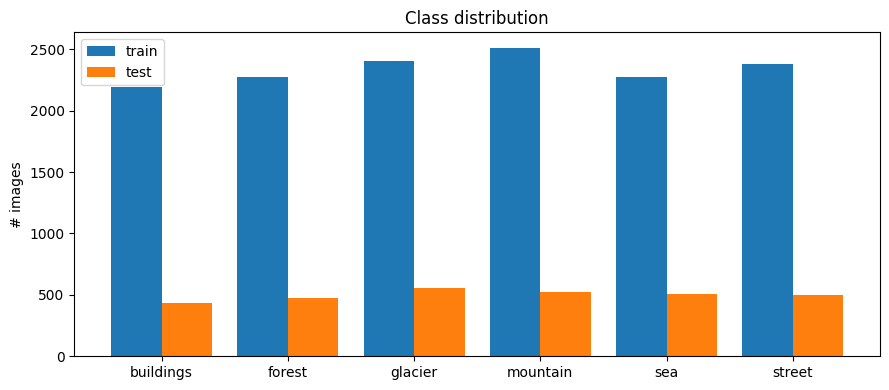

In [3]:
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print("Number of classes:", NUM_CLASSES, CLASS_NAMES)

def count_images(d):
    return {c: len(os.listdir(os.path.join(d, c))) for c in CLASS_NAMES}

train_counts, test_counts = count_images(TRAIN_DIR), count_images(TEST_DIR)
print("Train:", train_counts, "| total =", sum(train_counts.values()))
print("Test :", test_counts,  "| total =", sum(test_counts.values()))

x = np.arange(NUM_CLASSES); w = 0.4
plt.figure(figsize=(9,4))
plt.bar(x - w/2, [train_counts[c] for c in CLASS_NAMES], w, label="train")
plt.bar(x + w/2, [test_counts[c]  for c in CLASS_NAMES], w, label="test")
plt.xticks(x, CLASS_NAMES); plt.ylabel("# images"); plt.title("Class distribution"); plt.legend()
plt.tight_layout(); plt.show()

Most common (width, height): [((150, 150), 1992), ((150, 97), 1), ((150, 135), 1), ((150, 113), 1), ((150, 136), 1)]
Distinct sizes in sample: 9


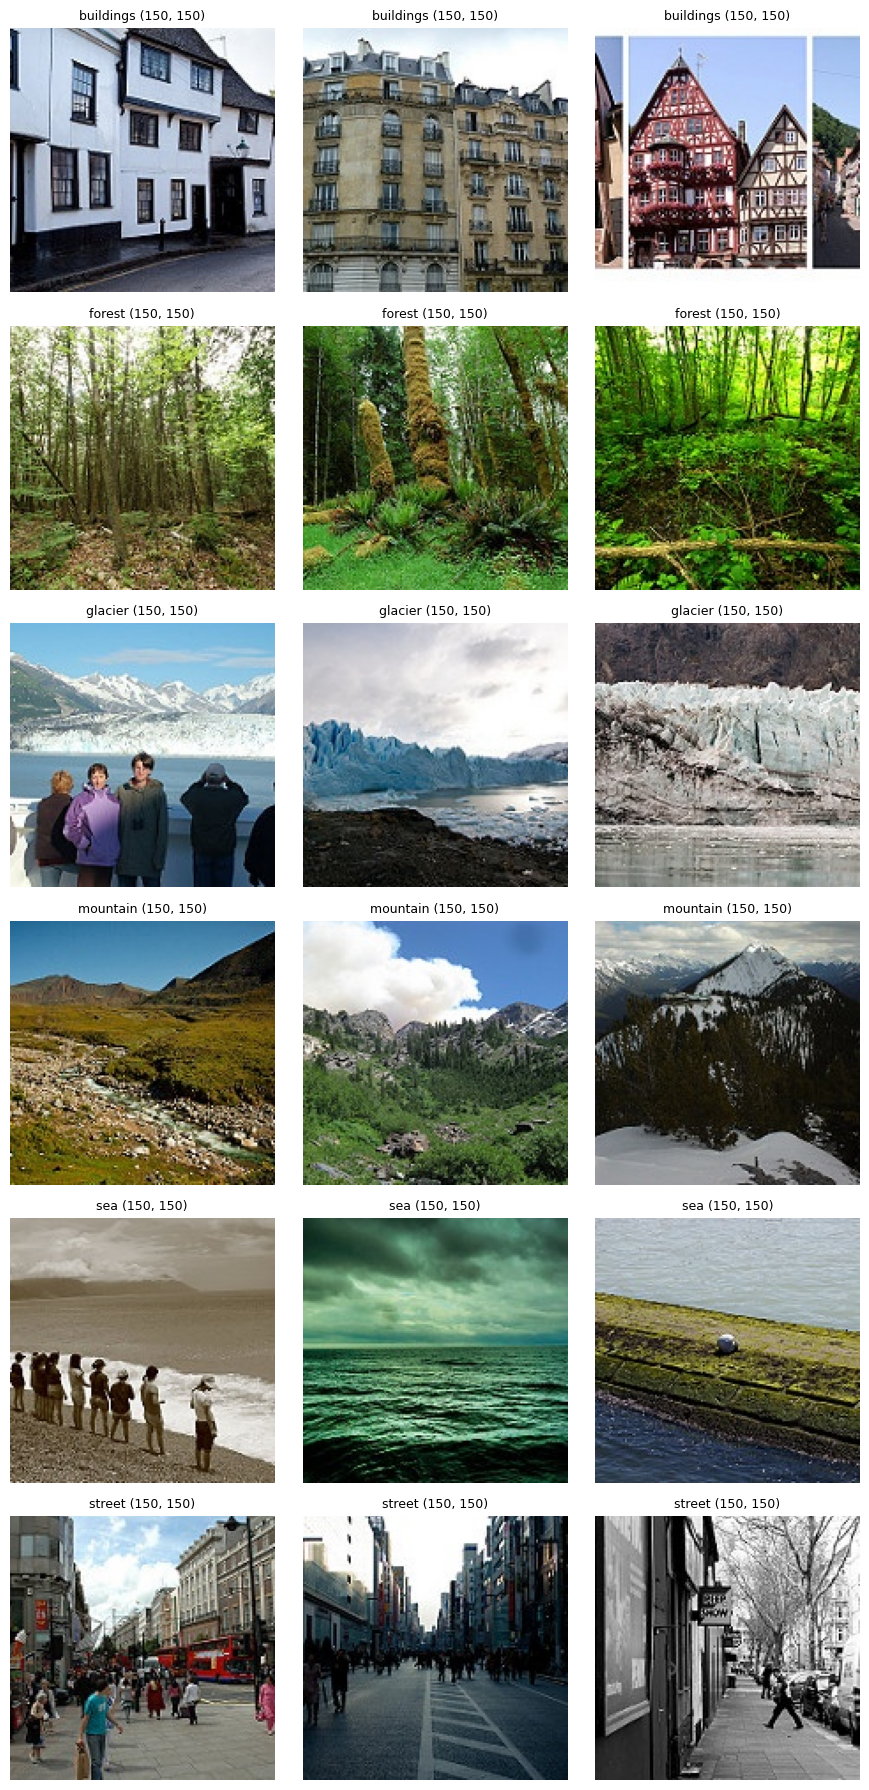

In [4]:
all_paths = [(os.path.join(TRAIN_DIR, c, f), c) for c in CLASS_NAMES for f in os.listdir(os.path.join(TRAIN_DIR, c))]
sample = random.sample(all_paths, 2000)
size_counter = collections.Counter(Image.open(p).size for p, _ in sample)
print("Most common (width, height):", size_counter.most_common(5))
print("Distinct sizes in sample:", len(size_counter))

# Sample images 3/class
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(9, 3*NUM_CLASSES))
for i, c in enumerate(CLASS_NAMES):
    files = random.sample(os.listdir(os.path.join(TRAIN_DIR, c)), 3)
    for j, f in enumerate(files):
        img = Image.open(os.path.join(TRAIN_DIR, c, f))
        axes[i, j].imshow(img); axes[i, j].axis("off")
        axes[i, j].set_title(f"{c} {img.size}", fontsize=9)
plt.tight_layout(); plt.show()

### A2. Preprocessing
- **Resize** to 150×150.
- **Split:** the dataset ships with `seg_train` (~14k) and `seg_test` (3k, labelled). I use `seg_test` as the **held-out test set** and split `seg_train` **80/20** into **train/validation**.
- **Normalize:** pixel values are rescaled from [0,255] to [0,1] using a `Rescaling` layer inside the model.
- **Augmentation:** random flip, rotation, zoom and shift, implemented as Keras layers. They are active **only during training**, so validation and test data are never augmented.

In [5]:
IMG_SIZE = (150, 150)
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, label_mode="int", class_names=CLASS_NAMES)
val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, label_mode="int", class_names=CLASS_NAMES)
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH, label_mode="int",
    class_names=CLASS_NAMES, shuffle=False)          # shuffle=False keeps label order for evaluation

print("Batches -> train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Batches -> train: 351 val: 88 test: 94


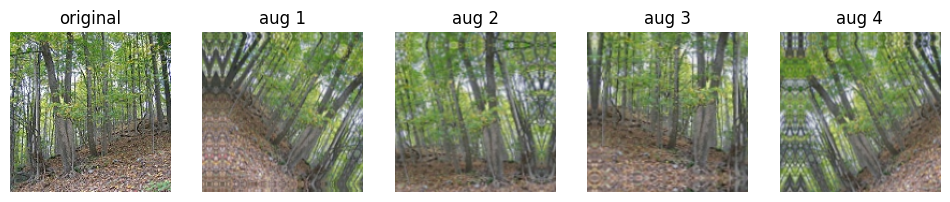

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),            # about +/- 29 degrees
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),     # height / width shift
], name="augmentation")

# Visualize augmentation on one training image
for images, labels in train_ds.take(1):
    img = images[0:1]
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 5, 1); plt.imshow(img[0].numpy().astype("uint8")); plt.title("original"); plt.axis("off")
    for i in range(4):
        aug = data_augmentation(img, training=True)
        plt.subplot(1, 5, i+2); plt.imshow(aug[0].numpy().astype("uint8")); plt.title(f"aug {i+1}"); plt.axis("off")
    plt.show()

## Part B: CNN Model Development
### B3. Architecture
Input - Augmentation - Rescaling - **4 × [Conv - BatchNorm - ReLU - Conv - BatchNorm - ReLU - MaxPool - Dropout]** (32-64-128-256 filters)  
GlobalAveragePooling - Dense(256, ReLU) - Dropout(0.5) - Dense(6, softmax)

That is 8 convolutional layers, well above the required minimum of 3. Regularization comes from dropout, batch norm and augmentation.

In [7]:
def conv_block(x, filters, drop):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    return layers.Dropout(drop)(x)

def build_model():
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)                       # normalization
    for f, d in [(32, 0.1), (64, 0.15), (128, 0.2), (256, 0.25)]:
        x = conv_block(x, f, d)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="intel_cnn")

model = build_model()
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "intel_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,242,470 (4.74 MB)

 Trainable params: 1,240,550 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

### B4. Training with early stopping, checkpointing and LR scheduling

1.   List item
2.   List item



In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint("best_intel_cnn.keras", monitor="val_accuracy",
                                    save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=40, callbacks=callbacks)

Epoch 1/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4824 - loss: 1.3195
Epoch 1: val_accuracy improved from None to 0.46187, saving model to best_intel_cnn.keras

Epoch 1: finished saving model to best_intel_cnn.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 174ms/step - accuracy: 0.5515 - loss: 1.1311 - val_accuracy: 0.4619 - val_loss: 1.4834 - learning_rate: 0.0010
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6766 - loss: 0.8819
Epoch 2: val_accuracy improved from 0.46187 to 0.72452, saving model to best_intel_cnn.keras

Epoch 2: finished saving model to best_intel_cnn.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.6836 - loss: 0.8565 - val_accuracy: 0.7245 - val_loss: 0.7733 - learning_rate: 0.0010
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7269 - loss: 0.7510
Epoch 3: val_accuracy did not improve from 0.72452
351/351 ━━━━━━━━━━━━━━━━━━━━ 57s 162ms/step - accuracy: 0.7260 - loss: 0.7524 - val_accuracy: 0.6743 -

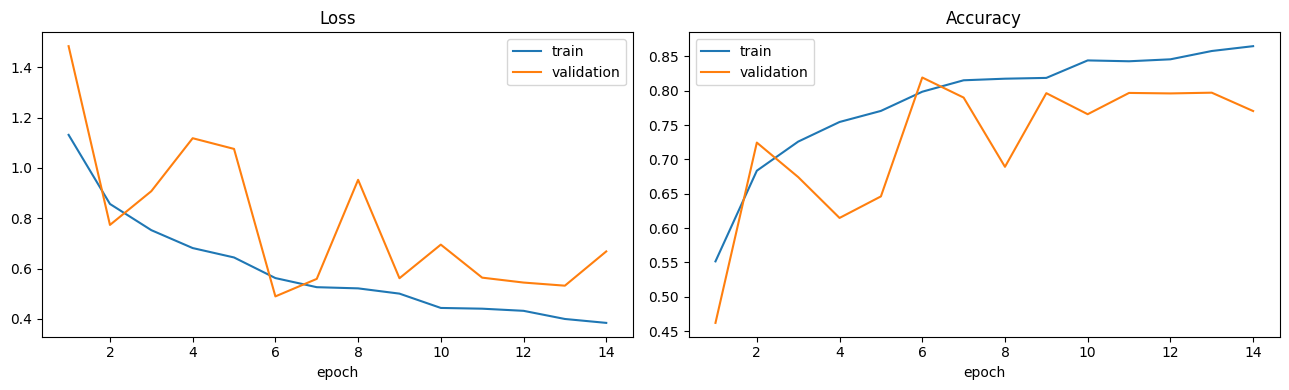

Best val accuracy: 0.8193 | Best val loss: 0.4893


In [9]:
h = history.history
epochs = range(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(epochs, h["loss"], label="train"); ax[0].plot(epochs, h["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, h["accuracy"], label="train"); ax[1].plot(epochs, h["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Best val accuracy: {max(h['val_accuracy']):.4f} | Best val loss: {min(h['val_loss']):.4f}")

## Part C: Model Evaluation and Interpretation
### C5. Test-set metrics

In [10]:
model = keras.models.load_model("best_intel_cnn.keras")     # best checkpoint

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# Gather test images / labels (test_ds is not shuffled, so order matches predictions)
x_test = np.concatenate([x.numpy().astype("uint8") for x, _ in test_ds])
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

print("Sanity check accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("\nPer-class precision / recall / F1:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Test loss: 0.4878 | Test accuracy: 0.8167
Sanity check accuracy: 0.8167

Per-class precision / recall / F1:

              precision    recall  f1-score   support

   buildings     0.7013    0.8970    0.7871       437
      forest     0.9705    0.9705    0.9705       474
     glacier     0.7593    0.7414    0.7502       553
    mountain     0.7478    0.7962    0.7712       525
         sea     0.8630    0.7784    0.8186       510
      street     0.9142    0.7445    0.8207       501

    accuracy                         0.8167      3000
   macro avg     0.8260    0.8213    0.8197      3000
weighted avg     0.8257    0.8167    0.8175      3000



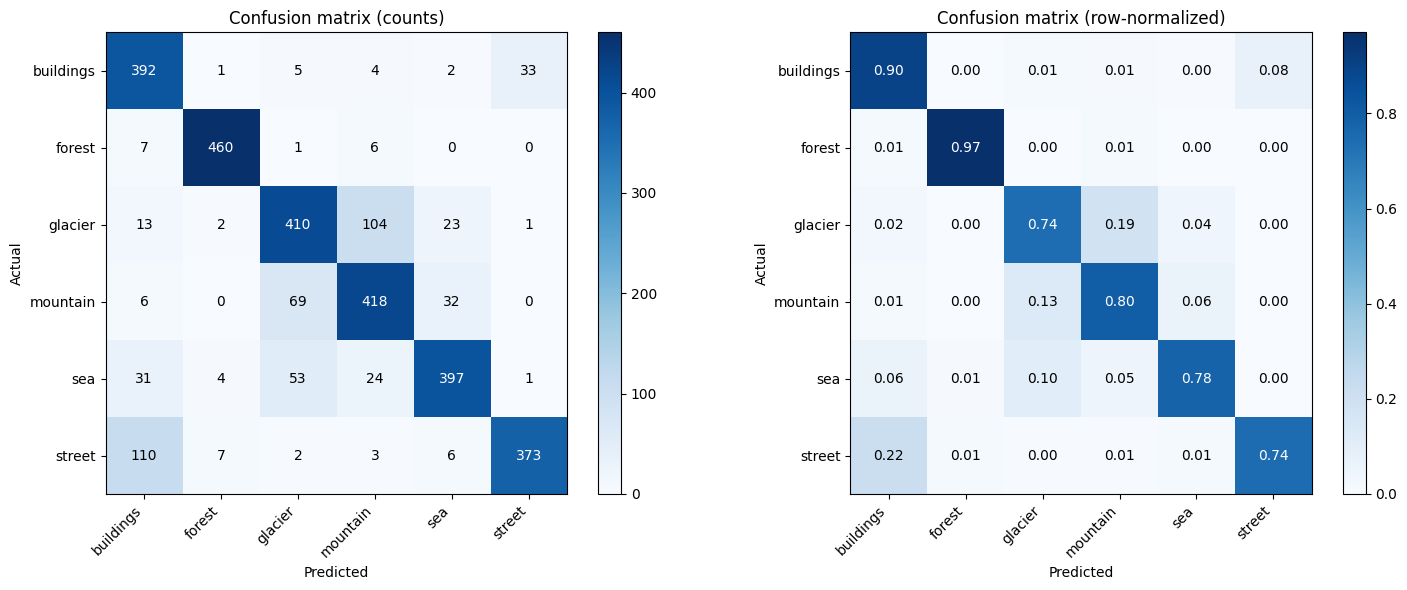

Top confusions (actual -> predicted):
     street -> buildings: 110
    glacier -> mountain : 104
   mountain -> glacier  : 69
        sea -> glacier  : 53
  buildings -> street   : 33


In [11]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, title, fmt in [(axes[0], cm, "Confusion matrix (counts)", "d"),
                             (axes[1], cm_norm, "Confusion matrix (row-normalized)", ".2f")]:
    im = ax.imshow(data, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                    color="white" if data[i, j] > data.max()/2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

# Most frequent confusions
pairs = [(CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j]) for i in range(NUM_CLASSES)
         for j in range(NUM_CLASSES) if i != j]
print("Top confusions (actual -> predicted):")
for a, p, n in sorted(pairs, key=lambda t: -t[2])[:5]:
    print(f"  {a:>9} -> {p:<9}: {n}")

### C6. Predicted vs. actual for 10 random test images

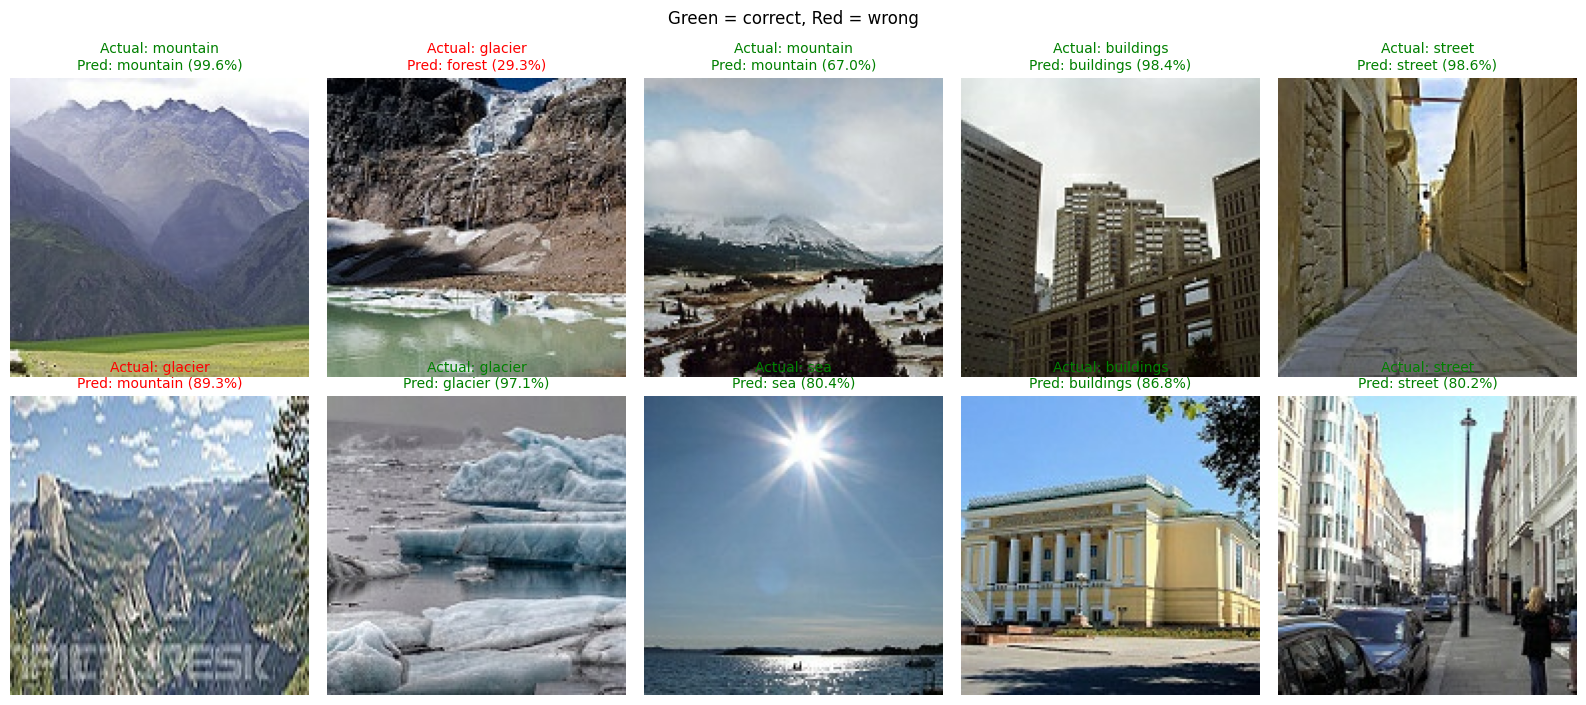

In [12]:
idx = np.random.choice(len(x_test), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(x_test[i]); ax.axis("off")
    ok = y_pred[i] == y_true[i]
    ax.set_title(f"Actual: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]} ({y_prob[i].max()*100:.1f}%)",
                 color="green" if ok else "red", fontsize=10)
plt.suptitle("Green = correct, Red = wrong", y=1.0)
plt.tight_layout(); plt.show()

Misclassified: 550 / 3000


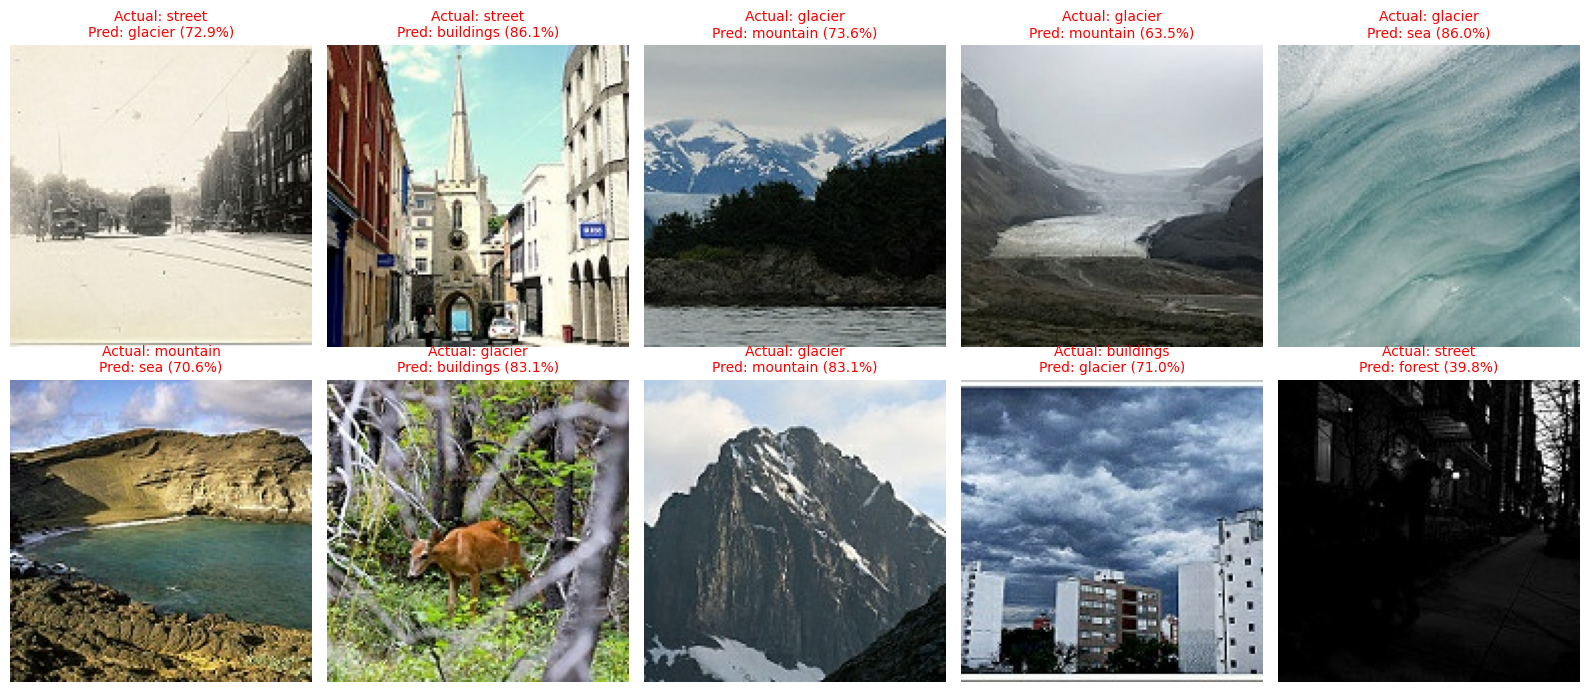

In [13]:
#any misclassified examples for error analysis
wrong = np.where(y_pred != y_true)[0]
print(f"Misclassified: {len(wrong)} / {len(y_true)}")
show = np.random.choice(wrong, min(10, len(wrong)), replace=False)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, i in zip(axes.ravel(), show):
    ax.imshow(x_test[i]); ax.axis("off")
    ax.set_title(f"Actual: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]} ({y_prob[i].max()*100:.1f}%)",
                 color="red", fontsize=10)
plt.tight_layout(); plt.show()

## Discussion on results
- **Overall performance. The model reaches 81.7% test accuracy (loss 0.488) with a macro F1 of 0.820 (macro precision 0.826, macro recall 0.821). That matches the best validation result (81.9%, loss 0.489), so the checkpoint didn't overfit to the validation set.

- **Easiest classes:** Forest is clearly the easiest, with precision, recall and F1 all at 0.97. Sea and street come next (F1 ≈ 0.82). Sea has good precision (0.86) but lower recall (0.78). Street has high precision (0.91) but the lowest recall of any class (0.74).

- **Hardest classes:** Glacier (F1 0.75) and mountain (0.77) are weakest. The main confusions are:

street → buildings: 110 images (22% of street). This is also why buildings' precision is low (0.70).
glacier → mountain: 104 images (19%).
mountain → glacier: 69 images (13%).
sea → glacier: 53 images (10%).


- **Generalization:** Training accuracy rose from 55% to 86.5% over 14 epochs. Validation accuracy was erratic (0.46–0.82) and plateaued near 80%. Early stopping restored the epoch-6 weights.

The train/validation gap is small to moderate, about 5–7 points. Training accuracy is measured with augmentation and dropout switched on, so it understates the model's fit.

The model looks under-trained and unstable more than overfit.

- **Possible improvements:** Use milder rotation, since scenes have a natural "up" direction.